# All_Beauty 필드 분포

01이 규모·스플릿·롱테일을 봤다면, 여기서는 **컬럼마다** 분포를 본다.

- Processed: `interactions_*.parquet`, `items.parquet`
- Raw: 리뷰·메타 JSON에서 ID/장문이 아닌 필드

**카디널리티가 높은 필드는 값 분포를 그리지 않는다.**  
`user_id`, `item_id`, 리뷰 본문, 상품명처럼 unique가 너무 많으면 막대그래프가 의미가 없다.

- 범주형: `nunique <= CARD_MAX` 일 때만 막대
- 숫자(`rating`, `price`, `timestamp`): unique가 많아도 히스토그램
- 긴 텍스트: 값 대신 **길이**만 본다

In [11]:
from __future__ import annotations

import gzip
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd()
ROOT = cwd if (cwd / "data").exists() else cwd.parent
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

CARD_MAX = 40

print("ROOT:", ROOT)
print("CARD_MAX:", CARD_MAX)
print("processed exists:", (PROCESSED / "interactions_train.parquet").exists())
print("raw reviews exists:", (RAW / "All_Beauty.json.gz").exists())

ROOT: c:\Users\user\Desktop\Git Repository\why-this-product
CARD_MAX: 40
processed exists: True
raw reviews exists: True


## 헬퍼

`profile_columns`로 전 필드의 결측·unique를 한 표로 본다.  
`plot_field`는 규칙에 맞을 때만 그린다.

In [12]:
ID_OR_TEXT = {
    "user_id",
    "item_id",
    "reviewerID",
    "asin",
    "reviewerName",
    "reviewText",
    "review_text",
    "summary",
    "title",
    "description",
    "doc_text",
}
NUMERIC_ALWAYS = {"rating", "overall", "timestamp", "unixReviewTime", "price", "vote_n"}


def _is_hist_numeric(s: pd.Series, col: str) -> bool:
    # pandas는 bool을 numeric으로 본다. True/False는 히스토그램이 아니라 막대.
    if pd.api.types.is_bool_dtype(s):
        return False
    return col in NUMERIC_ALWAYS or pd.api.types.is_numeric_dtype(s)


def _missing_rate(s: pd.Series) -> float:
    if s.dtype == object or str(s.dtype) == "string":
        empty = s.isna() | s.astype(str).str.strip().isin(("", "None", "nan"))
        return float(empty.mean())
    return float(s.isna().mean())


def profile_columns(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        nunique = int(s.nunique(dropna=True))
        miss = _missing_rate(s)
        kind = "numeric" if _is_hist_numeric(s, col) else "categorical"
        if col in ID_OR_TEXT:
            decision = "skip (id/text)"
        elif kind == "numeric":
            decision = "hist"
        elif nunique > CARD_MAX:
            decision = f"skip (nunique={nunique:,} > {CARD_MAX})"
        else:
            decision = "bar"
        rows.append(
            {
                "column": col,
                "dtype": str(s.dtype),
                "n": n,
                "nunique": nunique,
                "missing": f"{miss:.1%}",
                "plot": decision,
            }
        )
    return pd.DataFrame(rows)


def plot_field(s: pd.Series, title: str, ax=None):
    name = title.split(":")[-1].strip() if ":" in title else title
    col = s.name or name
    if col in ID_OR_TEXT:
        print(f"skip {col}: id/text")
        return
    nunique = int(s.nunique(dropna=True))
    numeric = _is_hist_numeric(s, col)
    if not numeric and nunique > CARD_MAX:
        print(f"skip {col}: nunique={nunique:,} > CARD_MAX={CARD_MAX}")
        return

    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(8, 3.5))

    if numeric:
        vals = pd.to_numeric(s, errors="coerce").dropna()
        if col in {"timestamp", "unixReviewTime"}:
            years = pd.to_datetime(vals, unit="s").dt.year
            years.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
            ax.set_xlabel("year")
            ax.set_ylabel("count")
        else:
            ax.hist(vals, bins=min(40, max(10, vals.nunique())), color="steelblue", edgecolor="white")
            ax.set_xlabel(col)
            ax.set_ylabel("count")
    else:
        vc = s.fillna("(null)").astype(str).replace({"": "(empty)", "nan": "(null)"})
        vc = vc.value_counts().sort_index()
        vc.plot(kind="bar", ax=ax, color="coral")
        ax.set_xlabel(col)
        ax.set_ylabel("count")

    ax.set_title(title)
    if own:
        plt.tight_layout()
        plt.show()


def plot_text_length(s: pd.Series, title: str) -> None:
    lens = s.fillna("").astype(str).str.len()
    empty = (lens == 0).mean()
    print(f"{title}: empty={empty:.1%}, length median={lens.median():.0f}, p95={lens.quantile(0.95):.0f}")
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(lens[lens > 0], bins=40, color="seagreen", edgecolor="white")
    ax.set_title(f"{title} (char length, empty excluded)")
    ax.set_xlabel("characters")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

## 1. Processed interactions

train/valid/test를 이어 붙이고 `split` 컬럼을 둔다.

In [13]:
parts = []
for name in ("train", "valid", "test"):
    path = PROCESSED / f"interactions_{name}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"{path} 없음. prepare_splits 먼저 실행.")
    df = pd.read_parquet(path)
    df["split"] = name
    parts.append(df)

inter = pd.concat(parts, ignore_index=True)
print("interactions:", len(inter), "cols:", list(inter.columns))
display(profile_columns(inter))

interactions: 357081 cols: ['user_id', 'item_id', 'rating', 'timestamp', 'review_text', 'split']


,column,dtype,n,nunique,missing,plot
0,user_id,str,357081,319335,0.0%,skip (id/text)
1,item_id,str,357081,32486,0.0%,skip (id/text)
2,rating,float64,357081,5,0.0%,hist
3,timestamp,int64,357081,5282,0.0%,hist
4,review_text,str,357081,314507,0.1%,skip (id/text)
5,split,str,357081,3,0.0%,bar


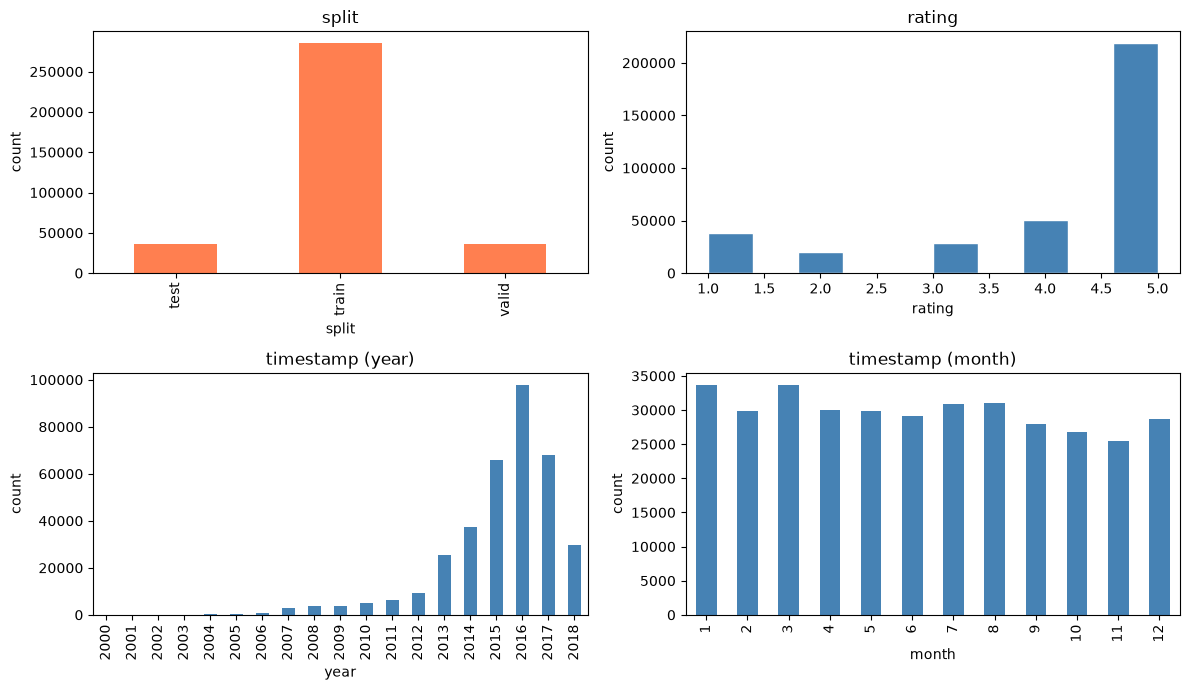

user_id nunique: 319335
item_id nunique: 32486
review_text: empty=0.1%, length median=116, p95=723


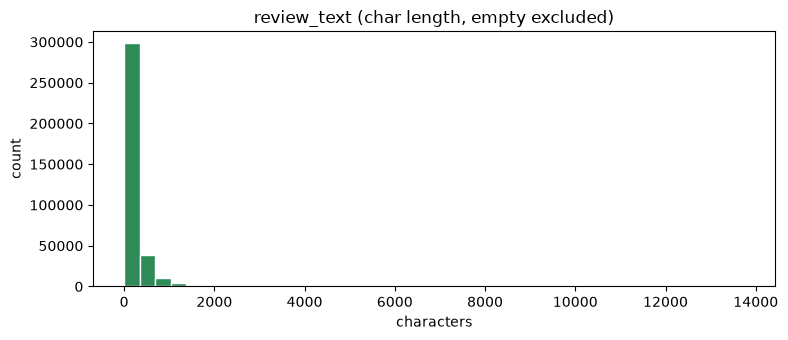

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_field(inter["split"], "split", axes[0, 0])
plot_field(inter["rating"], "rating", axes[0, 1])
plot_field(inter["timestamp"], "timestamp (year)", axes[1, 0])

months = pd.to_datetime(inter["timestamp"], unit="s").dt.month
months.value_counts().sort_index().plot(kind="bar", ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("timestamp (month)")
axes[1, 1].set_xlabel("month")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

print("user_id nunique:", inter["user_id"].nunique())
print("item_id nunique:", inter["item_id"].nunique())
plot_text_length(inter["review_text"], "review_text")

split × rating. 시간 분할이라 평점 비율이 구간마다 달라질 수 있다.

rating,1.0,2.0,3.0,4.0,5.0
split,,,,,
test,0.138,0.061,0.079,0.113,0.609
train,0.102,0.055,0.081,0.149,0.614
valid,0.123,0.058,0.082,0.124,0.613


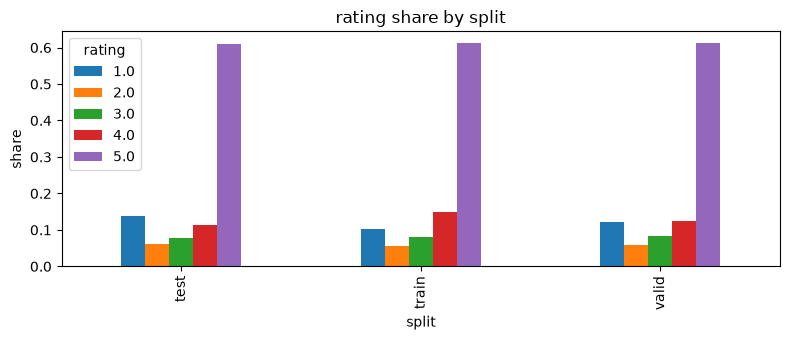

In [15]:
ct = pd.crosstab(inter["split"], inter["rating"], normalize="index")
display(ct.round(3))
ct.plot(kind="bar", figsize=(8, 3.5))
plt.title("rating share by split")
plt.ylabel("share")
plt.tight_layout()
plt.show()

## 2. Processed items

In [16]:
items = pd.read_parquet(PROCESSED / "items.parquet")
print("items:", len(items), "cols:", list(items.columns))
display(profile_columns(items))

items: 32488 cols: ['item_id', 'title', 'brand', 'category', 'description', 'price', 'doc_text']


,column,dtype,n,nunique,missing,plot
0,item_id,str,32488,32488,0.0%,skip (id/text)
1,title,str,32488,32297,0.0%,skip (id/text)
2,brand,str,32488,7862,47.9%,"skip (nunique=7,862 > 40)"
3,category,str,32488,1,0.0%,bar
4,description,str,32488,13735,54.4%,skip (id/text)
5,price,float64,32488,3523,65.1%,hist
6,doc_text,str,32488,32338,0.0%,skip (id/text)


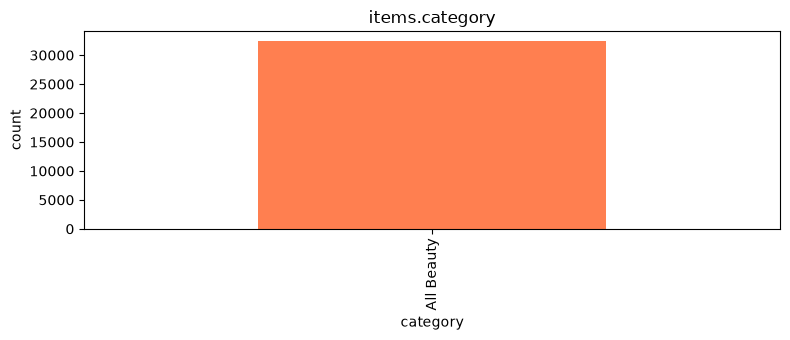

skip brand: nunique=7,862 > CARD_MAX=40


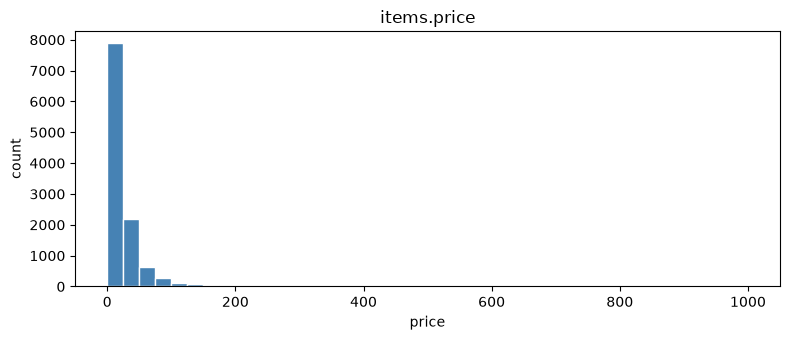

price missing: 65.1%
item_id nunique: 32488
items.title: empty=0.0%, length median=66, p95=153


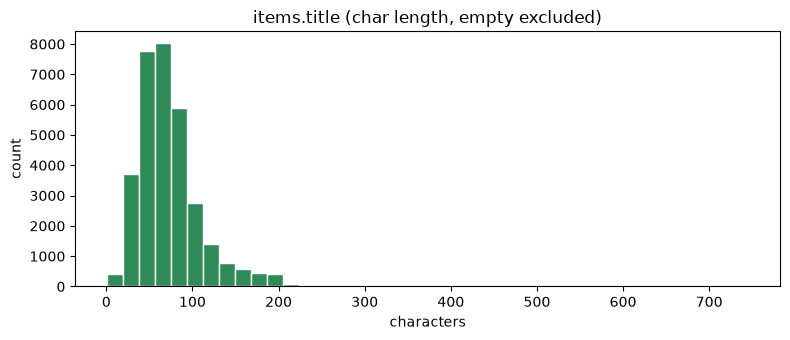

items.description: empty=54.4%, length median=0, p95=900


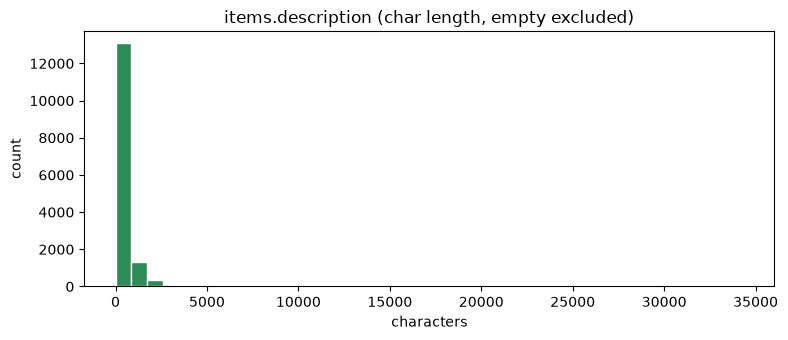

items.doc_text: empty=0.0%, length median=108, p95=995


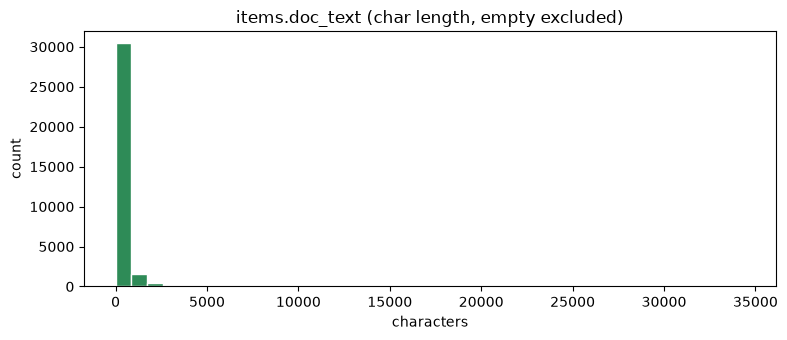

In [17]:
plot_field(items["category"], "items.category")
plot_field(items["brand"], "items.brand")
plot_field(items["price"], "items.price")

print("price missing:", f"{items['price'].isna().mean():.1%}")
print("item_id nunique:", items["item_id"].nunique())

for col in ("title", "description", "doc_text"):
    plot_text_length(items[col], f"items.{col}")

brand는 unique가 `CARD_MAX`를 넘으면 막대를 생략한다. 상위만 참고용으로 본다.

In [18]:
brand = items["brand"].fillna("(null)").replace("", "(empty)")
print("brand nunique:", brand.nunique())
display(brand.value_counts().head(20).rename("count").to_frame())

brand nunique: 7863


,count
brand,
(null),15570
VAGA,252
L'Oreal Paris,110
Betty Dain,82
Unknown,79
EG GIFTS,79
b.m.c,75
Gillette,73
Victoria's Secret,70


## 3. Raw reviews (ID/장문 제외)

processed에 없는 `verified`, `vote` 등을 본다. gzip 한 바퀴라 1~2분 걸릴 수 있다.

In [19]:
def iter_json_gz(path: Path):
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            line = (
                line.replace(": NaN", ": null")
                .replace(": Infinity", ": null")
                .replace(":-Infinity", ": null")
            )
            yield json.loads(line)


def parse_vote(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return None
    m = re.search(r"\d+", str(v).replace(",", ""))
    return int(m.group()) if m else None


review_path = RAW / "All_Beauty.json.gz"
if not review_path.exists():
    print("raw reviews 없음. skip")
    reviews_slim = None
else:
    rows = []
    key_counts: dict[str, int] = {}
    for obj in iter_json_gz(review_path):
        for k in obj:
            key_counts[k] = key_counts.get(k, 0) + 1
        rows.append(
            {
                "overall": obj.get("overall"),
                "verified": obj.get("verified"),
                "unixReviewTime": obj.get("unixReviewTime"),
                "vote_n": parse_vote(obj.get("vote")),
                "has_style": bool(obj.get("style")),
                "has_image": bool(obj.get("image")),
            }
        )
    reviews_slim = pd.DataFrame(rows)
    print("raw review keys (row coverage):")
    display(
        pd.Series(key_counts, name="rows")
        .sort_values(ascending=False)
        .to_frame()
        .assign(share=lambda d: d["rows"] / len(reviews_slim))
    )
    display(profile_columns(reviews_slim))

raw review keys (row coverage):


,rows,share
overall,371345,1.000000
verified,371345,1.000000
reviewTime,371345,1.000000
reviewerID,371345,1.000000
asin,371345,1.000000
unixReviewTime,371345,1.000000
reviewerName,371307,0.999898
summary,371139,0.999445
reviewText,370946,0.998926
style,125958,0.339194


,column,dtype,n,nunique,missing,plot
0,overall,float64,371345,5,0.0%,hist
1,verified,bool,371345,2,0.0%,bar
2,unixReviewTime,int64,371345,5288,0.0%,hist
3,vote_n,float64,371345,266,86.0%,hist
4,has_style,bool,371345,2,0.0%,bar
5,has_image,bool,371345,2,0.0%,bar


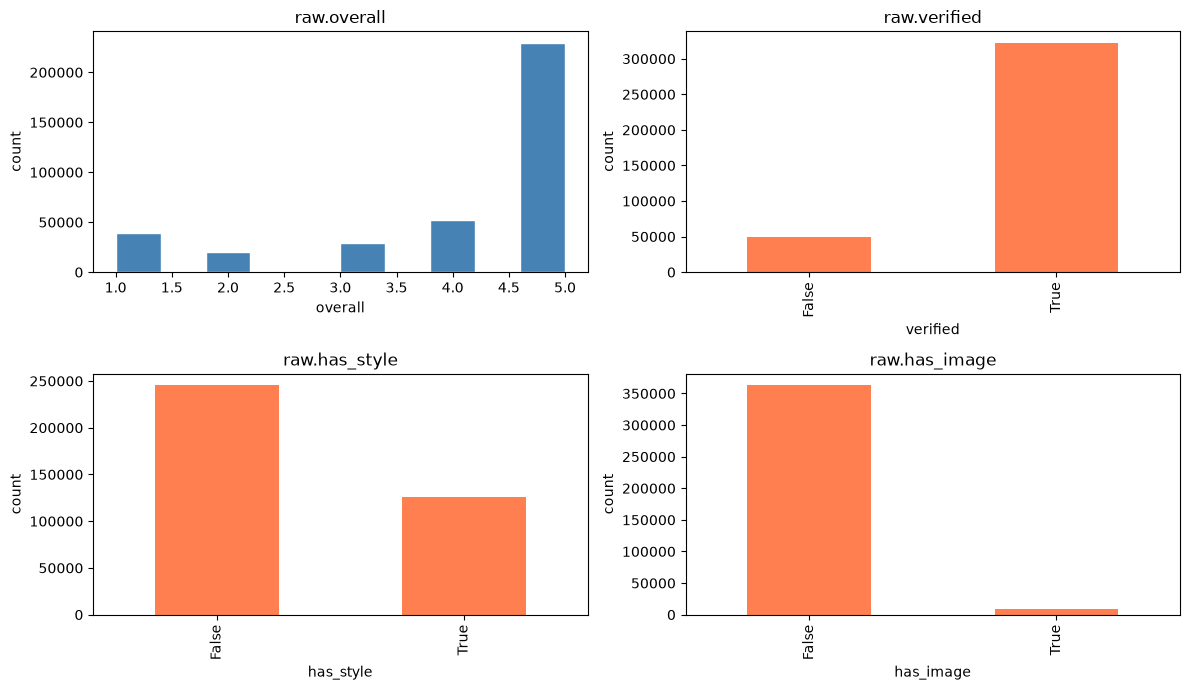

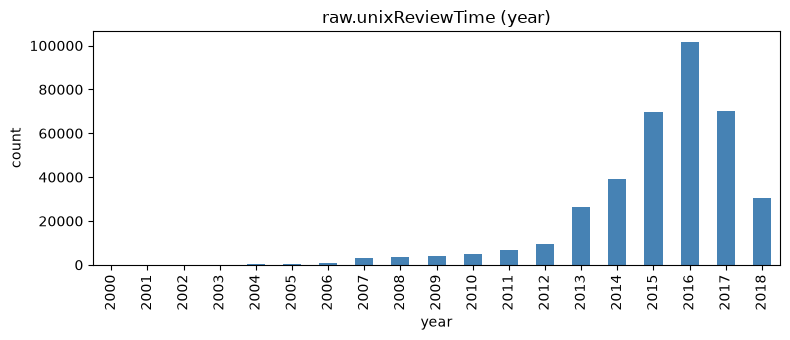

vote present: 51,899 / 371,345 (14.0%)


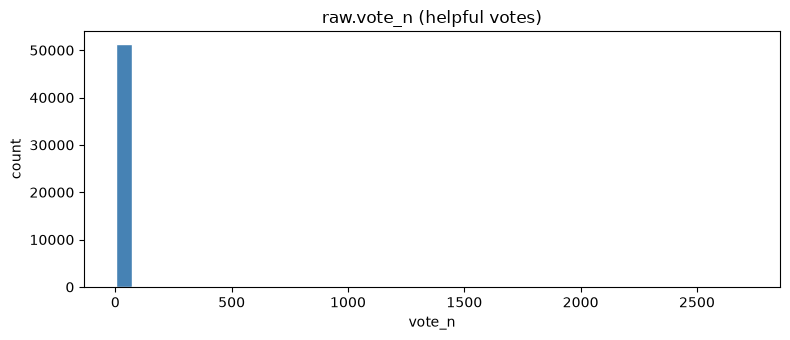

In [20]:
if reviews_slim is None:
    print("skip raw review plots")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    plot_field(reviews_slim["overall"], "raw.overall", axes[0, 0])
    plot_field(reviews_slim["verified"], "raw.verified", axes[0, 1])
    plot_field(reviews_slim["has_style"], "raw.has_style", axes[1, 0])
    plot_field(reviews_slim["has_image"], "raw.has_image", axes[1, 1])
    plt.tight_layout()
    plt.show()

    plot_field(reviews_slim["unixReviewTime"], "raw.unixReviewTime (year)")
    voted = reviews_slim["vote_n"].dropna()
    print(f"vote present: {len(voted):,} / {len(reviews_slim):,} ({len(voted)/len(reviews_slim):.1%})")
    if len(voted):
        plot_field(reviews_slim["vote_n"], "raw.vote_n (helpful votes)")

## 4. Raw meta (ID/장문 제외)

리스트·빈 문자열은 “있음/없음”으로 줄인다. `also_buy` 같은 ASIN 목록은 카디널리티가 높아 길이와 존재 여부만 본다.

In [21]:
def nonempty(v) -> bool:
    if v is None:
        return False
    if isinstance(v, float) and pd.isna(v):
        return False
    if isinstance(v, (list, dict, str)):
        return len(v) > 0
    return True


def list_len(v) -> int:
    return len(v) if isinstance(v, list) else 0


def parse_price_raw(v):
    if v is None or v == "":
        return None
    if isinstance(v, (int, float)) and not pd.isna(v):
        return float(v)
    m = re.search(r"\d+(?:\.\d+)?", str(v))
    return float(m.group()) if m else None


meta_path = RAW / "meta_All_Beauty.json.gz"
if not meta_path.exists():
    print("raw meta 없음. skip")
    meta_slim = None
else:
    rows = []
    key_counts = {}
    for obj in iter_json_gz(meta_path):
        for k in obj:
            key_counts[k] = key_counts.get(k, 0) + 1
        rows.append(
            {
                "main_cat": obj.get("main_cat") or None,
                "brand": (str(obj.get("brand")).strip() or None) if obj.get("brand") is not None else None,
                "price": parse_price_raw(obj.get("price")),
                "has_category": nonempty(obj.get("category")),
                "has_description": nonempty(obj.get("description")),
                "has_feature": nonempty(obj.get("feature")),
                "has_rank": nonempty(obj.get("rank")),
                "has_also_buy": nonempty(obj.get("also_buy")),
                "has_also_view": nonempty(obj.get("also_view")),
                "has_image": nonempty(obj.get("imageURL")),
                "n_also_buy": list_len(obj.get("also_buy")),
                "n_also_view": list_len(obj.get("also_view")),
            }
        )
    meta_slim = pd.DataFrame(rows)
    print("raw meta keys (row coverage):")
    display(
        pd.Series(key_counts, name="rows")
        .sort_values(ascending=False)
        .to_frame()
        .assign(share=lambda d: d["rows"] / len(meta_slim))
    )
    display(profile_columns(meta_slim))

raw meta keys (row coverage):


,rows,share
category,32892,1.0
tech1,32892,1.0
description,32892,1.0
fit,32892,1.0
title,32892,1.0
also_buy,32892,1.0
tech2,32892,1.0
brand,32892,1.0
feature,32892,1.0
rank,32892,1.0


,column,dtype,n,nunique,missing,plot
0,main_cat,str,32892,1,0.0%,bar
1,brand,str,32892,7862,47.6%,"skip (nunique=7,862 > 40)"
2,price,float64,32892,3523,65.2%,hist
3,has_category,bool,32892,1,0.0%,bar
4,has_description,bool,32892,2,0.0%,bar
5,has_feature,bool,32892,2,0.0%,bar
6,has_rank,bool,32892,2,0.0%,bar
7,has_also_buy,bool,32892,2,0.0%,bar
8,has_also_view,bool,32892,2,0.0%,bar
9,has_image,bool,32892,2,0.0%,bar


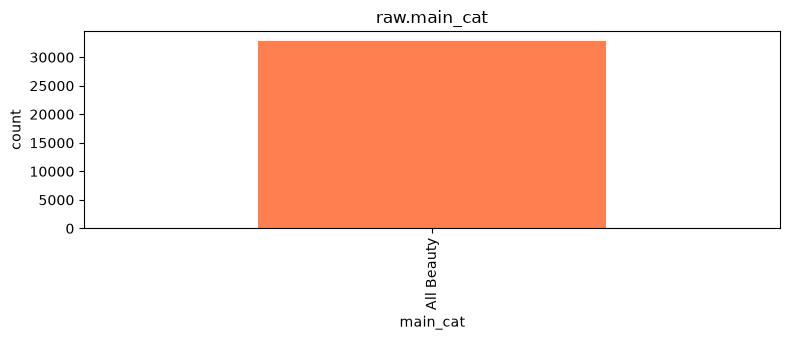

skip brand: nunique=7,862 > CARD_MAX=40


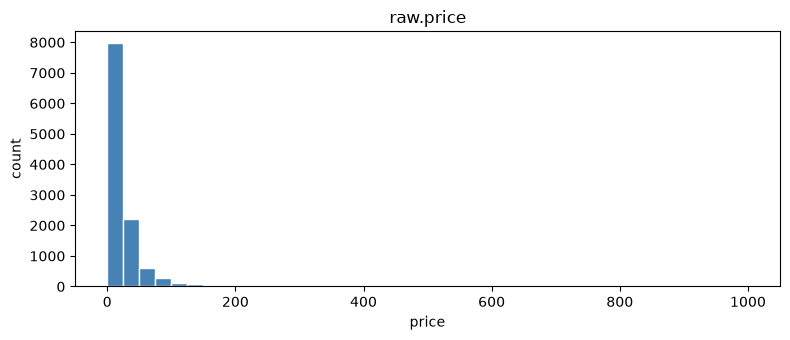

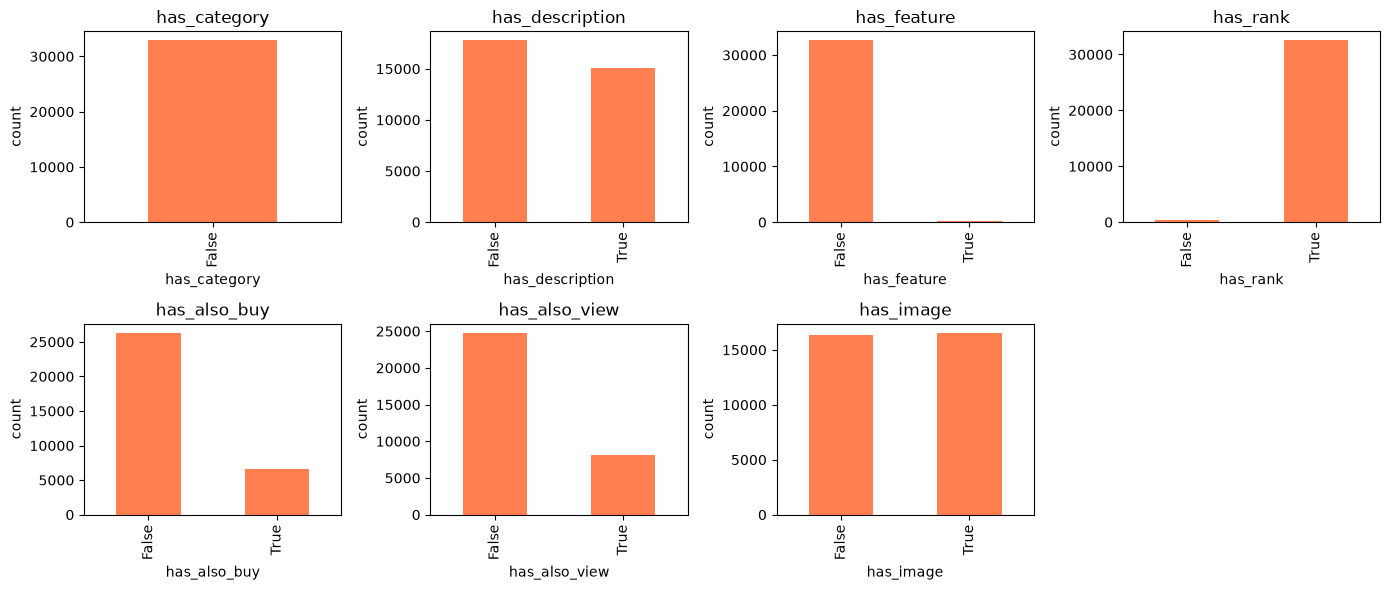

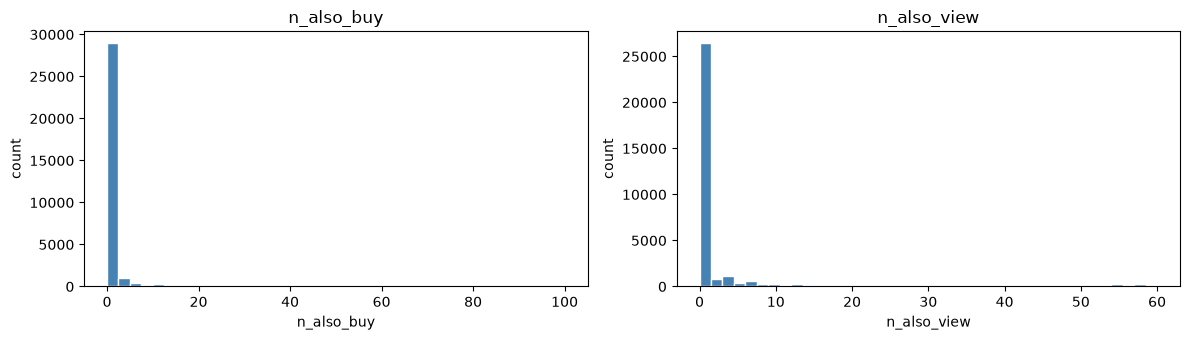

In [22]:
if meta_slim is None:
    print("skip raw meta plots")
else:
    plot_field(meta_slim["main_cat"], "raw.main_cat")
    plot_field(meta_slim["brand"], "raw.brand")
    plot_field(meta_slim["price"], "raw.price")

    flags = [
        "has_category",
        "has_description",
        "has_feature",
        "has_rank",
        "has_also_buy",
        "has_also_view",
        "has_image",
    ]
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for ax, col in zip(axes.ravel(), flags):
        plot_field(meta_slim[col], col, ax)
    axes.ravel()[-1].axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    plot_field(meta_slim["n_also_buy"], "n_also_buy", axes[0])
    plot_field(meta_slim["n_also_view"], "n_also_view", axes[1])
    plt.tight_layout()
    plt.show()

## Takeaway

- `CARD_MAX`를 바꾸면 brand 같은 중간 카디널리티 필드도 막대로 볼 수 있다.
- ID·장문은 값 분포 대신 unique 수와 텍스트 길이를 본다.
- raw `verified` / `vote` / `also_buy`는 processed 스키마에 없으므로, 나중에 feature로 쓸지 여기서 판단한다.